# Marketing Campaign A/B Test: Did the Ads Increase Conversions?

**Business question.** A company ran an ad campaign. A randomly assigned control group saw a
public service announcement (PSA) in the same ad slots instead of the ad. Did the ad increase
conversions compared with the PSA, and is continuing the campaign worth it?

| Item | Definition |
|---|---|
| Unit of analysis | One user (one row) |
| Treatment | `ad`: user saw the campaign ad |
| Control | `psa`: user saw a public service announcement in the same placement |
| Primary metric | Conversion rate = converted users / users in the group |
| H0 | Conversion rate (ad) = conversion rate (PSA) |
| H1 | Conversion rate (ad) > conversion rate (PSA), one-sided |
| Significance level | α = 0.05 |
| Target power | 0.80 |
| Main estimate | Absolute lift (percentage points) and relative lift (%), each with a 95% confidence interval |

**Known limits, written down before any analysis**

1. **No timestamps.** We cannot see test duration, novelty effects, or whether lift fades over time.
2. **No cost or revenue data.** Any business-value estimate needs labeled assumptions.
3. **No pre-assignment user attributes** (age, device, region). We cannot check covariate balance.
4. **No guardrail metrics** (unsubscribes, complaints, page speed). We cannot check for harm.
5. **Exposure columns are measured after assignment.** `total_ads`, `most_ads_day` and
   `most_ads_hour` describe what each user saw during the test, not who they were before it.
   Any analysis that slices by them is exploratory, not causal.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import (
    proportions_ztest, confint_proportions_2indep, proportion_confint, proportion_effectsize)
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.multitest import multipletests

ALPHA, POWER = 0.05, 0.80
DATA = Path("../data/marketing_AB.csv")
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
REPORTS = Path("../reports"); REPORTS.mkdir(exist_ok=True)
results = {}   # every headline number is stored here and written to reports/results.json

# Chart style: one consistent, colorblind-checked palette for every figure.
AD, PSA = "#2a78d6", "#eb6834"          # blue = ad, orange = PSA (the same in every chart)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": INK2, "ytick.color": INK2, "grid.color": GRID, "grid.linewidth": 0.8,
    "legend.frameon": False, "font.size": 10,
    "text.parse_math": False,   # so "$" in titles prints as a dollar sign
})
pp_fmt = mtick.FuncFormatter(lambda v, _: f"{round(v*100, 2):+g}" if v else "0")   # proportion -> percentage points
pct = mtick.PercentFormatter(xmax=1, decimals=1)
pct2 = mtick.PercentFormatter(xmax=1, decimals=2)

## 1. Data audit

The CSV comes from Kaggle ("Marketing A/B Testing", by faviovaz). The first column is an unnamed
row index, so it is read as the index. Column names contain spaces, which are replaced with
underscores so they work as Python attributes and SQL identifiers.

In [2]:
df = pd.read_csv(DATA, index_col=0)
df.columns = df.columns.str.replace(" ", "_")
print(df.shape)
df.head()

(588101, 6)


,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [3]:
df.dtypes

user_id          int64
test_group         str
converted         bool
total_ads        int64
most_ads_day       str
most_ads_hour    int64
dtype: object

### Data quality checks

Each check below is run in code, and the table shows its outcome.

In [4]:
valid_days = {"Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"}
checks = pd.DataFrame([
    ("Rows", f"{len(df):,}"),
    ("Missing values (all columns)", int(df.isna().sum().sum())),
    ("Duplicate user_id", int(df.user_id.duplicated().sum())),
    ("Fully duplicated rows", int(df.duplicated().sum())),
    ("test_group values", ", ".join(sorted(df.test_group.unique()))),
    ("converted is boolean", str(df.converted.dtype) == "bool"),
    ("total_ads minimum (should be >= 1)", int(df.total_ads.min())),
    ("total_ads maximum", int(df.total_ads.max())),
    ("most_ads_day values all valid weekdays", set(df.most_ads_day.unique()) <= valid_days),
    ("most_ads_hour range (should be 0 to 23)", f"{df.most_ads_hour.min()} to {df.most_ads_hour.max()}"),
], columns=["Check", "Outcome"])
checks

,Check,Outcome
0,Rows,"588,101"
1,Missing values (all columns),0
2,Duplicate user_id,0
3,Fully duplicated rows,0
4,test_group values,"ad, psa"
5,converted is boolean,True
6,total_ads minimum (should be >= 1),1
7,total_ads maximum,2065
8,most_ads_day values all valid weekdays,True
9,most_ads_hour range (should be 0 to 23),0 to 23


All checks pass: no missing values, no duplicate users, valid categories, and exposure values
in plausible ranges. `total_ads` has a long right tail (a maximum in the thousands against a
median in the teens), which is why exposure is analysed later in buckets rather than as a raw
number.

In [5]:
df.describe()

,user_id,total_ads,most_ads_hour
count,5.881010e+05,588101.000000,588101.000000
mean,1.310692e+06,24.820876,14.469061
std,2.022260e+05,43.715181,4.834634
min,9.000000e+05,1.000000,0.000000
25%,1.143190e+06,4.000000,11.000000
50%,1.313725e+06,13.000000,14.000000
75%,1.484088e+06,27.000000,18.000000
max,1.654483e+06,2065.000000,23.000000


### Group sizes: the split is very lopsided

In [6]:
sizes = df.test_group.value_counts().rename("users").to_frame()
sizes["share"] = sizes.users / sizes.users.sum()
results["n_total"] = int(len(df))
results["n_ad"], results["n_psa"] = int(sizes.loc["ad", "users"]), int(sizes.loc["psa", "users"])
results["share_psa"] = float(sizes.loc["psa", "share"])
sizes.style.format({"users": "{:,}", "share": "{:.2%}"})

,users,share
test_group,,
ad,"564,577",96.00%
psa,"23,524",4.00%


Only about 4% of users are in the control (PSA) group. What this means:

* **We cannot run a sample ratio mismatch (SRM) test.** An SRM test compares the observed split
  with the split the experiment was *designed* to have. The designed split is not documented.
  Testing against the observed split would pass by construction, so it proves nothing.
* **A small control group can be deliberate.** Companies often keep the holdout small to limit
  the revenue lost by not showing ads. We cannot prove from this data whether 96/4 was intended.
* **Precision is set by the small group.** The standard error of the difference is dominated by
  the PSA group's variance, so the effective sample size is much closer to the PSA count than to
  the total. The 588K headline overstates how much information we have.

### Were both groups exposed the same way?

A randomized test should give both groups similar exposure patterns. These variables are
post-assignment, so this is a sanity check rather than a balance test. With samples this large,
tiny differences become "significant," so an effect size is reported next to every p-value:
Cramér's V for the categorical columns, the KS statistic for `total_ads`.

In [7]:
def cramers_v(table):
    chi2, p, dof, _ = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    return chi2, p, np.sqrt(chi2 / (n * (min(table.shape) - 1)))

rows = []
for col in ["most_ads_day", "most_ads_hour"]:
    chi2, p, v = cramers_v(pd.crosstab(df[col], df.test_group))
    rows.append((col, "chi-square", round(chi2, 1), p, round(v, 3), "Cramér's V"))
ks = stats.ks_2samp(df.loc[df.test_group == "ad", "total_ads"], df.loc[df.test_group == "psa", "total_ads"])
rows.append(("total_ads", "Kolmogorov-Smirnov", round(ks.statistic, 3), ks.pvalue, round(ks.statistic, 3), "KS D"))
balance = pd.DataFrame(rows, columns=["variable", "test", "statistic", "p_value", "effect_size", "effect_size_type"])
results["balance_max_effect_size"] = float(balance.effect_size.max())
balance

,variable,test,statistic,p_value,effect_size,effect_size_type
0,most_ads_day,chi-square,235.60,4.849068e-48,0.020,Cramér's V
1,most_ads_hour,chi-square,192.30,1.094574e-28,0.018,Cramér's V
2,total_ads,Kolmogorov-Smirnov,0.04,2.342651e-31,0.040,KS D


In [8]:
print(df.groupby("test_group").total_ads.describe().round(1))

               count  mean   std  min  25%   50%   75%     max
test_group                                                    
ad          564577.0  24.8  43.8  1.0  4.0  13.0  27.0  2065.0
psa          23524.0  24.8  42.9  1.0  4.0  12.0  26.0   907.0


The p-values are tiny, but every effect size is small (well below 0.1). The exposure patterns
differ slightly between groups: PSA users were served on a slightly different day and hour mix.
This does not break the test, because group assignment still decides which creative a user saw.
It is one more reason to treat the segment results in Section 4 as exploratory, and it motivates
the adjusted sensitivity check in Section 2.

## 2. Primary result: two-proportion z-test

**Why this test.** Each user either converts or not, so each group's conversion count is
binomial. With thousands of users per group and hundreds of conversions in each, the normal
approximation to the difference in proportions is accurate. The test assumes independent users,
random assignment, and one observation per user; the audit confirmed there are no duplicate users.

The **pooled** z-test is used for the p-value because under H0 both groups share one rate. The
confidence interval uses the **unpooled** (Wald) standard error, because it describes the
difference we actually observed. Using `method="wald"` also makes the interval directly
comparable with R's `prop.test`.

In [9]:
ad  = df.loc[df.test_group == "ad",  "converted"].astype(int)
psa = df.loc[df.test_group == "psa", "converted"].astype(int)
count, nobs = np.array([ad.sum(), psa.sum()]), np.array([len(ad), len(psa)])

z, p_value = proportions_ztest(count, nobs, alternative="larger")

p_ad, p_psa = ad.mean(), psa.mean()
abs_lift = p_ad - p_psa
rel_lift = abs_lift / p_psa

# 95% CI for the absolute difference (Wald, two-sided)
diff_lo, diff_hi = confint_proportions_2indep(count[0], nobs[0], count[1], nobs[1],
                                              compare="diff", method="wald", alpha=ALPHA)
# 95% CI for the ratio p_ad / p_psa (log method). Relative lift = ratio - 1.
ratio_lo, ratio_hi = confint_proportions_2indep(count[0], nobs[0], count[1], nobs[1],
                                                compare="ratio", method="log", alpha=ALPHA)
rel_lo, rel_hi = ratio_lo - 1, ratio_hi - 1

# Per-group 95% Wilson intervals (for the bar chart)
ci_ad  = proportion_confint(count[0], nobs[0], alpha=ALPHA, method="wilson")
ci_psa = proportion_confint(count[1], nobs[1], alpha=ALPHA, method="wilson")

results.update(conv_ad=count[0].item(), conv_psa=count[1].item(), rate_ad=p_ad, rate_psa=p_psa,
               abs_lift=abs_lift, abs_lift_ci=[diff_lo, diff_hi],
               rel_lift=rel_lift, rel_lift_ci=[rel_lo, rel_hi], z=z, p_value=p_value)

summary = pd.DataFrame({
    "Metric": ["Users (ad / PSA)", "Conversions (ad / PSA)", "Conversion rate, ad", "Conversion rate, PSA",
               "Absolute lift", "95% CI, absolute lift", "Relative lift", "95% CI, relative lift",
               "z statistic (pooled, one-sided)", "p-value (one-sided)"],
    "Value": [f"{nobs[0]:,} / {nobs[1]:,}", f"{count[0]:,} / {count[1]:,}", f"{p_ad:.3%}", f"{p_psa:.3%}",
              f"{abs_lift*100:.3f} pp", f"[{diff_lo*100:.3f}, {diff_hi*100:.3f}] pp",
              f"{rel_lift:.1%}", f"[{rel_lo:.1%}, {rel_hi:.1%}]", f"{z:.3f}", f"{p_value:.2e}"],
})
summary

,Metric,Value
0,Users (ad / PSA),"564,577 / 23,524"
1,Conversions (ad / PSA),"14,423 / 420"
2,"Conversion rate, ad",2.555%
3,"Conversion rate, PSA",1.785%
4,Absolute lift,0.769 pp
5,"95% CI, absolute lift","[0.595, 0.943] pp"
6,Relative lift,43.1%
7,"95% CI, relative lift","[30.0%, 57.5%]"
8,"z statistic (pooled, one-sided)",7.370
9,p-value (one-sided),8.53e-14


In [10]:
print(f"The ad group converted at {p_ad:.2%} vs {p_psa:.2%} for PSA: "
      f"+{abs_lift*100:.2f} percentage points, a {rel_lift:.0%} relative lift "
      f"(95% CI {rel_lo:.0%} to {rel_hi:.0%}; one-sided p = {p_value:.1e}).")

The ad group converted at 2.55% vs 1.79% for PSA: +0.77 percentage points, a 43% relative lift (95% CI 30% to 58%; one-sided p = 8.5e-14).


**Reading the confidence interval in plain English.** If this experiment were repeated many
times and an interval computed the same way each time, about 95% of those intervals would contain
the true lift. Here the whole interval sits well above zero, so the data are inconsistent with
"the ad did nothing." Even the lower end of the relative-lift interval is a large improvement
over the PSA rate.

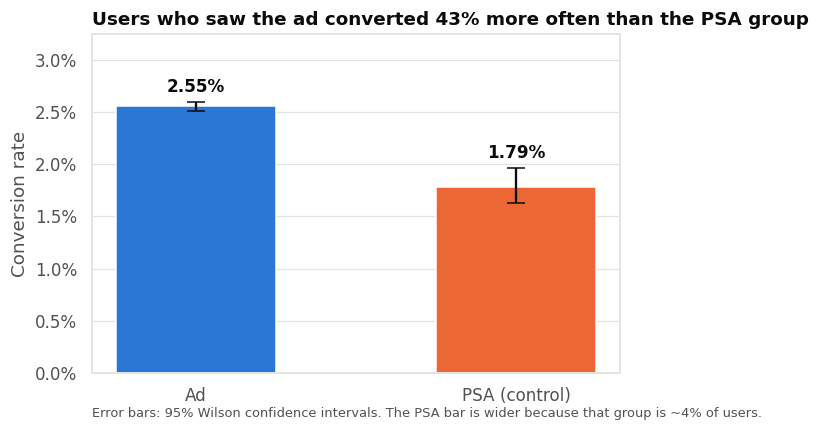

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 4))
rates = [p_ad, p_psa]
errs = np.array([[p_ad - ci_ad[0], p_psa - ci_psa[0]], [ci_ad[1] - p_ad, ci_psa[1] - p_psa]])
ax.bar(["Ad", "PSA (control)"], rates, width=0.5, color=[AD, PSA], zorder=2)
ax.errorbar(["Ad", "PSA (control)"], rates, yerr=errs, fmt="none", ecolor=INK, elinewidth=1.5, capsize=6, zorder=3)
for i, (r, hi) in enumerate(zip(rates, [ci_ad[1], ci_psa[1]])):
    ax.text(i, hi + 0.0006, f"{r:.2%}", ha="center", va="bottom", color=INK, fontsize=11, fontweight="bold")
ax.yaxis.set_major_formatter(pct)
ax.set_ylim(0, max(ci_ad[1], ci_psa[1]) * 1.25)
ax.set_ylabel("Conversion rate")
ax.set_title(f"Users who saw the ad converted {rel_lift:.0%} more often than the PSA group")
ax.text(0, -0.13, "Error bars: 95% Wilson confidence intervals. The PSA bar is wider because that group is ~4% of users.",
        transform=ax.transAxes, fontsize=8.5, color=INK2)
ax.grid(axis="x", visible=False)
fig.savefig(FIG / "01_conversion_by_group.png")
plt.show()

### Robustness check 1: bootstrap

The bootstrap re-creates the experiment 10,000 times by resampling users with replacement within
each group, then recomputes the lift each time. The middle 95% of those lifts is the percentile
interval.

For a 0/1 outcome, resampling *n* users with replacement from a group with observed rate *p̂*
gives exactly a Binomial(*n*, *p̂*) count of conversions. So drawing binomials below is the same
thing as the ordinary nonparametric bootstrap, just much faster than resampling 588K rows. The
check is whether this simulation, which uses no normal approximation, lands on the same interval
as the z-test.

In [12]:
rng = np.random.default_rng(42)
B = 10_000
boot_ad  = rng.binomial(nobs[0], p_ad,  B) / nobs[0]
boot_psa = rng.binomial(nobs[1], p_psa, B) / nobs[1]
boot_abs = boot_ad - boot_psa
boot_rel = boot_abs / boot_psa

b_lo, b_hi = np.percentile(boot_abs, [2.5, 97.5])
br_lo, br_hi = np.percentile(boot_rel, [2.5, 97.5])
results.update(boot_abs_ci=[b_lo, b_hi], boot_rel_ci=[br_lo, br_hi], boot_share_le_zero=float((boot_abs <= 0).mean()))

pd.DataFrame({
    "Method": ["z-test (Wald)", "Bootstrap percentile"],
    "Absolute lift 95% CI (pp)": [f"[{diff_lo*100:.3f}, {diff_hi*100:.3f}]", f"[{b_lo*100:.3f}, {b_hi*100:.3f}]"],
    "Relative lift 95% CI": [f"[{rel_lo:.1%}, {rel_hi:.1%}]", f"[{br_lo:.1%}, {br_hi:.1%}]"],
})

,Method,Absolute lift 95% CI (pp),Relative lift 95% CI
0,z-test (Wald),"[0.595, 0.943]","[30.0%, 57.5%]"
1,Bootstrap percentile,"[0.597, 0.942]","[30.6%, 57.9%]"


In [13]:
print(f"Bootstrap resamples with lift <= 0: {(boot_abs <= 0).sum()} of {B:,}")

Bootstrap resamples with lift <= 0: 0 of 10,000


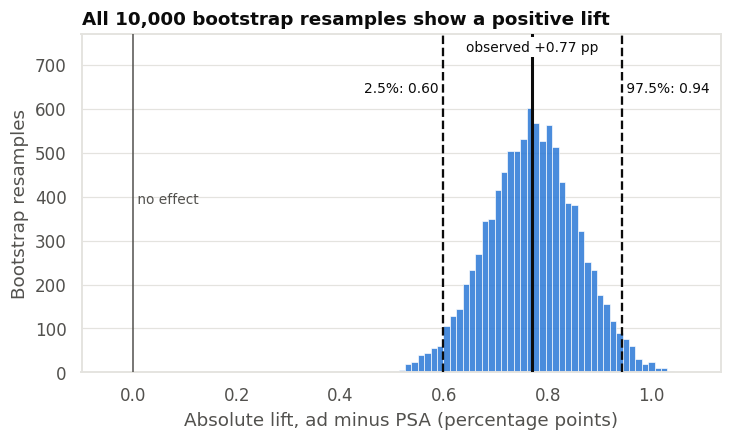

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(boot_abs * 100, bins=60, color=AD, alpha=0.85, edgecolor="white", linewidth=0.5, zorder=2)
for x in (b_lo, b_hi):
    ax.axvline(x * 100, color=INK, ls="--", lw=1.5, zorder=3)
ax.axvline(abs_lift * 100, color=INK, lw=2, zorder=3)
ax.axvline(0, color=INK2, lw=1, zorder=3)
ymax = ax.get_ylim()[1] * 1.22
ax.set_ylim(0, ymax)
ax.text(abs_lift * 100, ymax * 0.98, f"observed +{abs_lift*100:.2f} pp", color=INK, ha="center", va="top", fontsize=9,
        bbox=dict(fc="white", ec="none", pad=2), zorder=4)
ax.text(b_lo * 100, ymax * 0.86, f"2.5%: {b_lo*100:.2f} ", color=INK, ha="right", va="top", fontsize=9)
ax.text(b_hi * 100, ymax * 0.86, f" 97.5%: {b_hi*100:.2f}", color=INK, ha="left", va="top", fontsize=9)
ax.text(0, ymax * 0.5, " no effect", color=INK2, fontsize=9)
ax.set_xlim(-0.1, None)
ax.set_xlabel("Absolute lift, ad minus PSA (percentage points)")
ax.set_ylabel("Bootstrap resamples")
ax.set_title("All 10,000 bootstrap resamples show a positive lift")
ax.grid(axis="x", visible=False)
fig.savefig(FIG / "02_bootstrap_lift.png")
plt.show()

### Robustness check 2: adjusting for exposure differences

The audit found that the two groups had slightly different exposure patterns. To check that the
lift is not an artifact of that, a logistic regression estimates the ad effect while holding
`total_ads` (log scale), day and hour fixed. This is a **sensitivity check, not the headline.**
The exposure variables were measured after assignment and could themselves be affected by the
treatment, so adjusting for them can bias the estimate. If the adjusted and unadjusted results
agree, the conclusion does not depend on the exposure imbalance.

The adjusted effect is reported as an **average marginal effect** (the average change in
conversion probability from switching a user from PSA to ad), which is on the same percentage-point
scale as the headline lift.

In [15]:
model_df = df.assign(ad=(df.test_group == "ad").astype(int), y=df.converted.astype(int),
                     log_ads=np.log(df.total_ads))
logit = smf.logit("y ~ ad + log_ads + C(most_ads_day) + C(most_ads_hour)", data=model_df).fit(disp=False)

# Average marginal effect of the ad: predicted rate if everyone saw the ad minus if everyone saw the PSA
ame = (logit.predict(model_df.assign(ad=1)) - logit.predict(model_df.assign(ad=0))).mean()
or_ad = np.exp(logit.params["ad"]); or_lo, or_hi = np.exp(logit.conf_int().loc["ad"])
results.update(adj_ame=float(ame), adj_odds_ratio=float(or_ad), adj_or_ci=[float(or_lo), float(or_hi)],
               adj_p=float(logit.pvalues["ad"]))

pd.DataFrame({
    "Estimate": ["Unadjusted absolute lift", "Adjusted average marginal effect", "Adjusted odds ratio (95% CI)"],
    "Value": [f"{abs_lift*100:.3f} pp", f"{ame*100:.3f} pp", f"{or_ad:.2f} [{or_lo:.2f}, {or_hi:.2f}]"],
})

,Estimate,Value
0,Unadjusted absolute lift,0.769 pp
1,Adjusted average marginal effect,0.759 pp
2,Adjusted odds ratio (95% CI),"1.48 [1.33, 1.63]"


After adjusting for exposure, the ad effect is nearly the same size as the unadjusted lift and
still clearly different from zero, so the headline conclusion does not rest on the exposure
imbalance. The headline
estimate remains the simple unadjusted comparison, because that is the one randomization protects.

## 3. Power and practical significance

**Minimum detectable effect (MDE).** Given these group sizes, what is the smallest true lift the
test would detect 80% of the time at α = 0.05? `NormalIndPower` works in Cohen's *h*
(a difference of arcsine-transformed proportions), so *h* is converted back into a conversion
rate by inverting the arcsine transform around the PSA rate. That inversion is exact, so no grid
search is needed. A closed-form normal approximation is computed as a cross-check.

In [16]:
ratio = nobs[1] / nobs[0]
mde_h = NormalIndPower().solve_power(nobs1=nobs[0], ratio=ratio, alpha=ALPHA, power=POWER, alternative="larger")

# Cohen's h = 2*arcsin(sqrt(p1)) - 2*arcsin(sqrt(p2)). Solve for p1 given h and p2 = PSA rate.
p_mde = np.sin(np.arcsin(np.sqrt(p_psa)) + mde_h / 2) ** 2
mde_abs = p_mde - p_psa
assert np.isclose(proportion_effectsize(p_mde, p_psa), mde_h)   # round-trip check

# Cross-check: (z_alpha + z_beta) * standard error of the difference at the PSA rate
se0 = np.sqrt(p_psa * (1 - p_psa) * (1 / nobs[0] + 1 / nobs[1]))
mde_closed = (stats.norm.ppf(1 - ALPHA) + stats.norm.ppf(POWER)) * se0

# Power actually achieved for the observed effect
obs_h = proportion_effectsize(p_ad, p_psa)
achieved_power = NormalIndPower().power(effect_size=obs_h, nobs1=nobs[0], ratio=ratio, alpha=ALPHA, alternative="larger")

# Effective sample size: the equal-split group size that gives the same precision
n_eff = 2 / (1 / nobs[0] + 1 / nobs[1])

results.update(mde_abs=mde_abs, mde_rel=mde_abs / p_psa, mde_closed_abs=mde_closed,
               achieved_power=achieved_power, n_effective_per_group=n_eff)
pd.DataFrame({
    "Quantity": ["MDE, absolute (80% power, α = 0.05)", "MDE, relative to PSA rate",
                 "MDE closed-form cross-check", "Observed absolute lift", "Observed lift / MDE",
                 "Power to detect the observed lift", "Equal-split sample size with the same precision (per group)"],
    "Value": [f"{mde_abs*100:.3f} pp", f"{mde_abs/p_psa:.1%}", f"{mde_closed*100:.3f} pp",
              f"{abs_lift*100:.3f} pp", f"{abs_lift/mde_abs:.1f}x", f"{achieved_power:.4f}", f"{n_eff:,.0f}"],
})

,Quantity,Value
0,"MDE, absolute (80% power, α = 0.05)",0.226 pp
1,"MDE, relative to PSA rate",12.6%
2,MDE closed-form cross-check,0.219 pp
3,Observed absolute lift,0.769 pp
4,Observed lift / MDE,3.4x
5,Power to detect the observed lift,1.0000
6,Equal-split sample size with the same precisio...,"45,166"


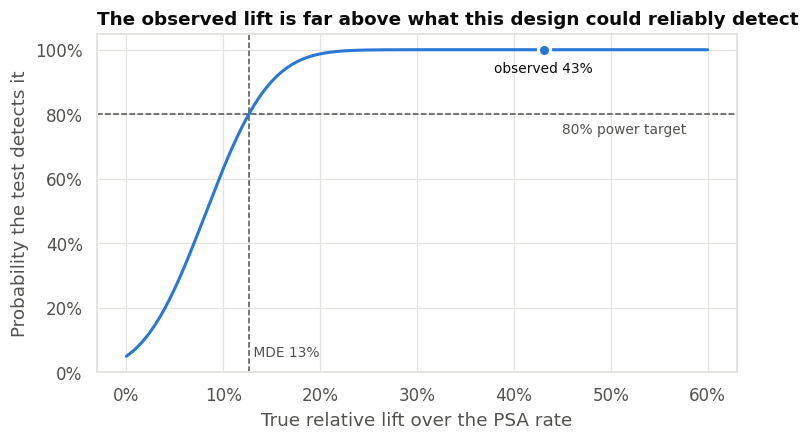

In [17]:
# Power curve: how likely this design is to detect each size of true relative lift
rel_grid = np.linspace(0, 0.6, 241)
power_curve = [NormalIndPower().power(effect_size=proportion_effectsize(p_psa * (1 + r), p_psa),
                                      nobs1=nobs[0], ratio=ratio, alpha=ALPHA, alternative="larger")
               if r > 0 else ALPHA for r in rel_grid]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(rel_grid, power_curve, color=AD, lw=2, zorder=3)
ax.axhline(POWER, color=INK2, lw=1, ls="--")
ax.axvline(mde_abs / p_psa, color=INK2, lw=1, ls="--")
ax.plot(rel_lift, achieved_power, "o", ms=8, color=AD, mec="white", mew=2, zorder=4)
ax.text(mde_abs / p_psa, 0.05, f" MDE {mde_abs/p_psa:.0%}", color=INK2, fontsize=9)
ax.text(rel_lift, achieved_power - 0.07, f"observed {rel_lift:.0%}", color=INK, ha="center", fontsize=9)
ax.text(0.45, POWER - 0.06, "80% power target", color=INK2, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 1.05)
ax.set_xlabel("True relative lift over the PSA rate")
ax.set_ylabel("Probability the test detects it")
ax.set_title("The observed lift is far above what this design could reliably detect")
fig.savefig(FIG / "06_power_curve.png")
plt.show()

**Statistical versus practical significance.**

* *Smallest reliable lift.* This design detects a true lift of about the MDE shown above with 80%
  probability. Because the PSA group is small, that MDE is roughly the size a balanced test with
  the "equal-split" sample size would give, not what 588K balanced users would give.
* *Why significance is not enough.* With hundreds of thousands of users, a very small lift can
  produce a tiny p-value. A p-value only says the lift is unlikely to be zero; it says nothing
  about whether the lift is large enough to pay for the ads. That question needs the effect size,
  its interval, and costs, which Section 5 covers.
* *Here.* The observed lift is several times the MDE, and even the low end of its confidence
  interval is well above the MDE. The result is both statistically clear and large in relative
  terms. Whether it is *worth the money* is a separate question that depends on assumptions.

## 4. Segment analysis (exploratory)

**These results are exploratory, not causal.** The segment variables were measured after
assignment, and users were not randomized into exposure levels. A higher conversion rate among
heavily exposed users could come from more engaged users both seeing more ads and converting
more, not from the ads themselves.

**Segments tested (15 in total), decided before looking at segment results:**

| Dimension | Segments | Why this grouping |
|---|---|---|
| `most_ads_day` | 7 weekdays | Natural categories |
| `most_ads_hour` | 4 dayparts: Night 0–5, Morning 6–11, Afternoon 12–17, Evening 18–23 | Several single hours have fewer than 5 PSA conversions (some have 0), so per-hour tests have almost no power and would add 24 comparisons |
| `total_ads` | 1–5, 6–20, 21–50, 51+ | Roughly quartile-like groups with enough PSA users in each |

**Method per segment.** Newcombe (score-based) 95% intervals for the lift, since they behave well
with small counts. One-sided Fisher's exact test for the p-value, since it is valid even when a
segment has very few conversions. **Holm correction** across all 15 tests controls the chance of
any false positive.

**Asking the right question.** "Is the lift positive in segment X?" is not the same as "does the
lift *differ* between segments?" The second question is answered with a likelihood-ratio test of
a group × segment interaction in a logistic regression, one test per dimension.

In [18]:
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["daypart"] = pd.cut(df.most_ads_hour, bins=[-1, 5, 11, 17, 23],
                       labels=["Night (0-5)", "Morning (6-11)", "Afternoon (12-17)", "Evening (18-23)"])
df["ads_bucket"] = pd.cut(df.total_ads, bins=[0, 5, 20, 50, np.inf], labels=["1-5", "6-20", "21-50", "51+"])

def segment_lift(data, col, order):
    rows = []
    for seg in order:
        s = data[data[col] == seg]
        a, c = s.loc[s.test_group == "ad", "converted"], s.loc[s.test_group == "psa", "converted"]
        ka, na, kc, nc = int(a.sum()), len(a), int(c.sum()), len(c)
        lo, hi = confint_proportions_2indep(ka, na, kc, nc, compare="diff", method="newcomb")
        _, p = stats.fisher_exact([[ka, na - ka], [kc, nc - kc]], alternative="greater")
        rows.append(dict(dimension=col, segment=str(seg), users_ad=na, users_psa=nc, conv_psa=kc,
                         rate_ad=ka / na, rate_psa=kc / nc, abs_lift=ka / na - kc / nc,
                         ci_lo=lo, ci_hi=hi, p_raw=p))
    return pd.DataFrame(rows)

seg = pd.concat([
    segment_lift(df, "most_ads_day", DAYS),
    segment_lift(df, "daypart", df.daypart.cat.categories),
    segment_lift(df, "ads_bucket", df.ads_bucket.cat.categories),
], ignore_index=True)

reject, p_holm, _, _ = multipletests(seg.p_raw, alpha=ALPHA, method="holm")
seg["p_holm"], seg["significant_after_holm"] = p_holm, reject
results.update(n_segments_tested=int(len(seg)), n_segments_significant_holm=int(reject.sum()))
results["share_users_20_or_fewer_ads"] = float((df.total_ads <= 20).mean())

(seg.style
    .format({"users_ad": "{:,}", "users_psa": "{:,}", "rate_ad": "{:.2%}", "rate_psa": "{:.2%}",
             "abs_lift": "{:+.2%}", "ci_lo": "{:+.2%}", "ci_hi": "{:+.2%}", "p_raw": "{:.2e}", "p_holm": "{:.2e}"})
    .hide(axis="index"))

dimension,segment,users_ad,users_psa,conv_psa,rate_ad,rate_psa,abs_lift,ci_lo,ci_hi,p_raw,p_holm,significant_after_holm
most_ads_day,Monday,"83,571","3,502",79,3.32%,2.26%,+1.07%,+0.51%,+1.53%,1.58e-04,1.58e-03,True
most_ads_day,Tuesday,"74,572","2,907",42,3.04%,1.44%,+1.60%,+1.08%,+1.99%,3.20e-08,4.48e-07,True
most_ads_day,Wednesday,"77,418","3,490",55,2.54%,1.58%,+0.96%,+0.48%,+1.34%,1.00e-04,1.10e-03,True
most_ads_day,Thursday,"79,077","3,905",79,2.16%,2.02%,+0.14%,-0.36%,+0.55%,3.01e-01,9.02e-01,False
most_ads_day,Friday,"88,805","3,803",62,2.25%,1.63%,+0.62%,+0.15%,+0.99%,5.17e-03,2.58e-02,True
most_ads_day,Saturday,"78,802","2,858",40,2.13%,1.40%,+0.73%,+0.22%,+1.12%,3.04e-03,1.82e-02,True
most_ads_day,Sunday,"82,332","3,059",63,2.46%,2.06%,+0.40%,-0.17%,+0.86%,8.51e-02,3.41e-01,False
daypart,Night (0-5),"19,102",735,1,1.35%,0.14%,+1.21%,+0.56%,+1.42%,6.10e-04,4.88e-03,True
daypart,Morning (6-11),"136,526","5,727",72,2.12%,1.26%,+0.86%,+0.53%,+1.13%,1.15e-06,1.37e-05,True
daypart,Afternoon (12-17),"246,925","10,914",220,2.77%,2.02%,+0.75%,+0.46%,+1.01%,5.23e-07,6.81e-06,True


In [19]:
# Does the lift differ across segments? One likelihood-ratio test per dimension.
def interaction_lrt(col):
    d = df.assign(ad=(df.test_group == "ad").astype(int), y=df.converted.astype(int), seg=df[col].astype(str))
    base = smf.logit("y ~ ad + C(seg)", data=d).fit(disp=False)
    full = smf.logit("y ~ ad * C(seg)", data=d).fit(disp=False)
    lr = 2 * (full.llf - base.llf); dof = full.df_model - base.df_model
    return dict(dimension=col, LR_stat=round(lr, 2), df=int(dof), p_value=stats.chi2.sf(lr, dof))

het = pd.DataFrame([interaction_lrt(c) for c in ["most_ads_day", "daypart", "ads_bucket"]])
results["heterogeneity_p"] = dict(zip(het.dimension, het.p_value.astype(float)))
het

,dimension,LR_stat,df,p_value
0,most_ads_day,16.22,6,0.012623
1,daypart,10.80,3,0.012846
2,ads_bucket,24.13,3,0.000023


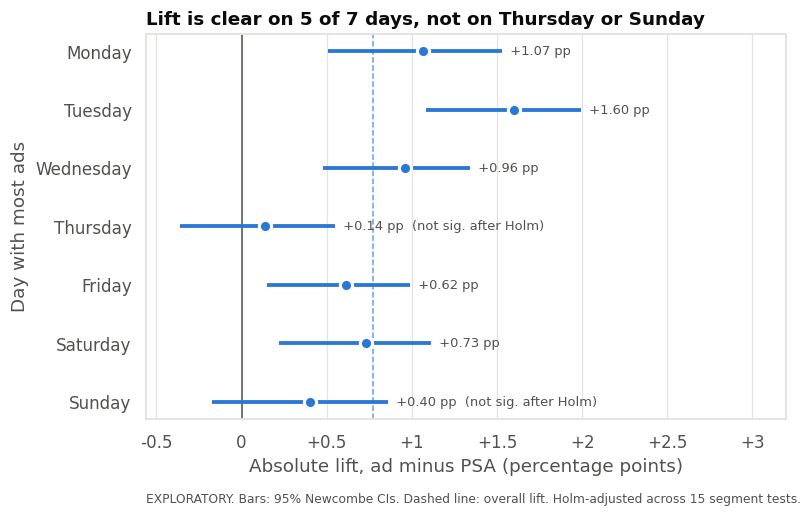

In [20]:
def forest(sub, title, fname, ylabel):
    sub = sub.iloc[::-1].reset_index(drop=True)          # first segment on top
    y = np.arange(len(sub))
    fig, ax = plt.subplots(figsize=(7.5, 0.45 * len(sub) + 1.4))
    ax.axvline(0, color=INK2, lw=1)
    ax.axvline(abs_lift, color=AD, lw=1, ls="--", alpha=0.7)
    ax.hlines(y, sub.ci_lo, sub.ci_hi, color=AD, lw=2.5, zorder=2)
    ax.plot(sub.abs_lift, y, "o", ms=8, color=AD, mec="white", mew=2, zorder=3)
    for yi, r in zip(y, sub.itertuples()):
        mark = "" if r.significant_after_holm else "  (not sig. after Holm)"
        ax.text(r.ci_hi, yi, f"  {r.abs_lift*100:+.2f} pp{mark}",
                va="center", fontsize=8.5, color=INK2)
    ax.set_yticks(y, sub.segment)
    ax.xaxis.set_major_formatter(pp_fmt)
    xmin = min(sub.ci_lo.min(), 0) - 0.002
    ax.set_xlim(xmin, sub.ci_hi.max() + 0.012)
    ax.set_xlabel("Absolute lift, ad minus PSA (percentage points)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.text(0, -0.02 - 0.9 / (0.45 * len(sub) + 1.4),
            "EXPLORATORY. Bars: 95% Newcombe CIs. Dashed line: overall lift. Holm-adjusted across 15 segment tests.",
            transform=ax.transAxes, fontsize=8, color=INK2)
    ax.grid(axis="y", visible=False)
    fig.savefig(FIG / fname)
    plt.show()

day = seg[seg.dimension == "most_ads_day"]
not_sig = day.loc[~day.significant_after_holm, "segment"].tolist()
forest(day, f"Lift is clear on {day.significant_after_holm.sum()} of 7 days, not on {' or '.join(not_sig)}",
       "03_lift_by_day.png", "Day with most ads")

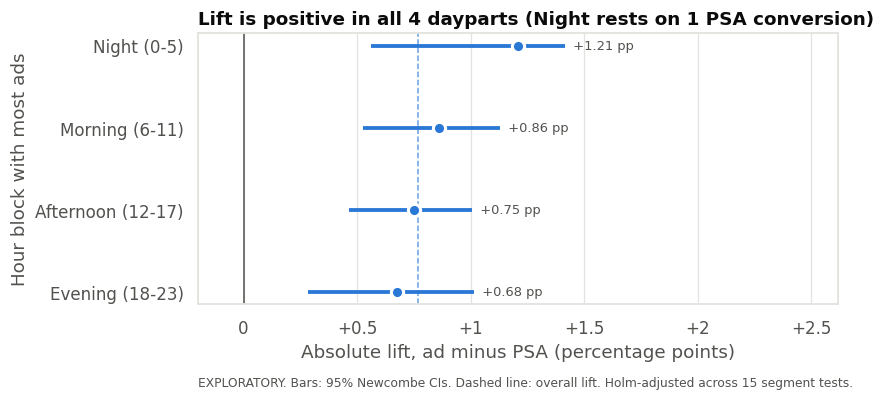

In [21]:
dp = seg[seg.dimension == "daypart"]
night_conv = int(dp.loc[dp.segment.str.startswith("Night"), "conv_psa"].iloc[0])
forest(dp, f"Lift is positive in all {len(dp)} dayparts (Night rests on {night_conv} PSA conversion)",
       "04_lift_by_daypart.png", "Hour block with most ads")

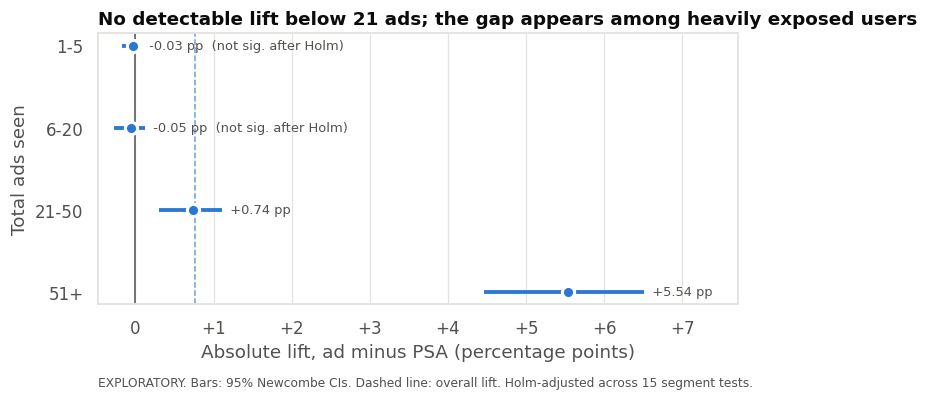

In [22]:
forest(seg[seg.dimension == "ads_bucket"],
       "No detectable lift below 21 ads; the gap appears among heavily exposed users",
       "05_lift_by_exposure.png", "Total ads seen")

**Descriptive view by hour.** For completeness, conversion rates for all 24 hours are shown
without significance tests. The PSA line is noisy because many hours have only a handful of PSA
conversions.

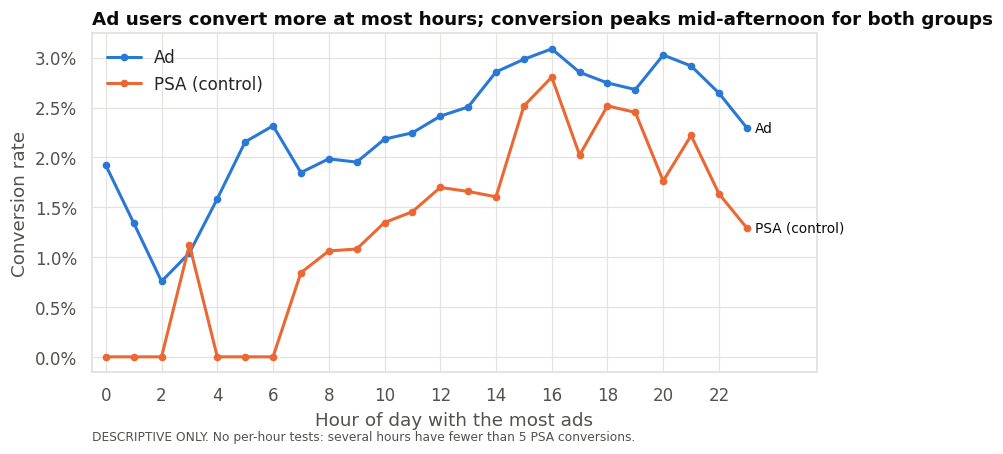

In [23]:
hourly = (df.groupby(["most_ads_hour", "test_group"]).converted.agg(["sum", "count"]).reset_index())
hourly["rate"] = hourly["sum"] / hourly["count"]
fig, ax = plt.subplots(figsize=(8.5, 4))
for g, color, label in [("ad", AD, "Ad"), ("psa", PSA, "PSA (control)")]:
    h = hourly[hourly.test_group == g]
    ax.plot(h.most_ads_hour, h.rate, color=color, lw=2, marker="o", ms=4, label=label, zorder=3)
    ax.text(23.3, h.rate.iloc[-1], label, color=INK, va="center", fontsize=9)
ax.yaxis.set_major_formatter(pct)
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(-0.5, 25.5)
ax.set_xlabel("Hour of day with the most ads")
ax.set_ylabel("Conversion rate")
ax.legend(loc="upper left")
ax.set_title("Ad users convert more at most hours; conversion peaks mid-afternoon for both groups")
ax.text(0, -0.2, "DESCRIPTIVE ONLY. No per-hour tests: several hours have fewer than 5 PSA conversions.",
        transform=ax.transAxes, fontsize=8, color=INK2)
fig.savefig(FIG / "07_conversion_by_hour.png")
plt.show()

**What the segments do and do not show**

* **Exposure is where the lift lives.** Users who saw 20 or fewer ads (the majority of users)
  show no detectable difference between ad and PSA. The gap appears at 21–50 ads and is largest at
  51+. The interaction test confirms the lift differs across exposure buckets.
* **This is an association, not a cause.** Exposure was not randomized within each group. Users
  who see many ads are probably more active on the site, and more active users convert more. The
  data cannot say whether showing *more* ads would create more conversions. A randomized
  frequency test is needed for that, and it is the most valuable follow-up.
* **Day and daypart.** The lift is positive in every daypart and on most days, but its size
  varies more than chance would explain. The Night block has very few PSA users and conversions,
  so its estimate is fragile. With no timestamps, day differences may reflect which calendar dates
  fell in the test, not a stable weekday pattern.
* **No "winning segment."** With 15 tests, some would look good by chance, which is what the
  Holm correction guards against.

## 5. Business impact

The data contain **no cost and no revenue**, so money figures below rely on assumptions. Rather
than invent a value per conversion, the model asks the question the business can answer:
**how much does a conversion need to be worth for the campaign to pay for itself?**

| Input | Value | Source |
|---|---|---|
| Users who saw the ad | from data | **Data** |
| Ad impressions served to the ad group | sum of `total_ads` for ad users | **Data** |
| Absolute lift (low / mid / high) | 95% CI lower bound / point estimate / upper bound | **Data (computed above)** |
| Cost per 1,000 impressions (CPM) | $2 / $5 / $10 | **ILLUSTRATIVE ASSUMPTION** (not in data) |
| Value per conversion | not assumed; solved for as a break-even value | **Output** |

Formulas:

* incremental conversions = users who saw the ad × absolute lift
* campaign cost = impressions ÷ 1,000 × CPM *(assumption)*
* **break-even value per conversion = campaign cost ÷ incremental conversions**
* net impact = incremental conversions × value per conversion − campaign cost *(assumption)*

The counterfactual is "what would have happened if these users had seen the PSA instead."

In [24]:
users_reached = int(nobs[0])
impressions = int(df.loc[df.test_group == "ad", "total_ads"].sum())
lift_scen = {"Low (CI lower)": diff_lo, "Mid (point est.)": abs_lift, "High (CI upper)": diff_hi}
CPM_ASSUMED = {"$2 CPM": 2.0, "$5 CPM": 5.0, "$10 CPM": 10.0}     # ILLUSTRATIVE ASSUMPTION

inc_conv = {k: users_reached * v for k, v in lift_scen.items()}
breakeven = pd.DataFrame({cpm_label: {k: (impressions / 1000 * cpm) / ic for k, ic in inc_conv.items()}
                          for cpm_label, cpm in CPM_ASSUMED.items()})
breakeven.index.name = "Lift scenario"

results.update(users_reached=users_reached, impressions_ad=impressions,
               incremental_conversions={k: float(v) for k, v in inc_conv.items()},
               cost_at_cpm={k: impressions / 1000 * v for k, v in CPM_ASSUMED.items()},
               breakeven_value_per_conversion={c: {k: float(v) for k, v in breakeven[c].items()} for c in breakeven})

print(f"Users who saw the ad: {users_reached:,}")
print(f"Ad impressions served: {impressions:,}")
for k, v in inc_conv.items():
    print(f"Incremental conversions, {k}: {v:,.0f}")
print("\nBreak-even value per conversion (campaign pays off above this). CPM is an ILLUSTRATIVE ASSUMPTION:")
breakeven.style.format("${:,.2f}")

Users who saw the ad: 564,577
Ad impressions served: 14,014,701
Incremental conversions, Low (CI lower): 3,360
Incremental conversions, Mid (point est.): 4,343
Incremental conversions, High (CI upper): 5,326

Break-even value per conversion (campaign pays off above this). CPM is an ILLUSTRATIVE ASSUMPTION:


,$2 CPM,$5 CPM,$10 CPM
Lift scenario,,,
Low (CI lower),$8.34,$20.86,$41.71
Mid (point est.),$6.45,$16.13,$32.27
High (CI upper),$5.26,$13.16,$26.31


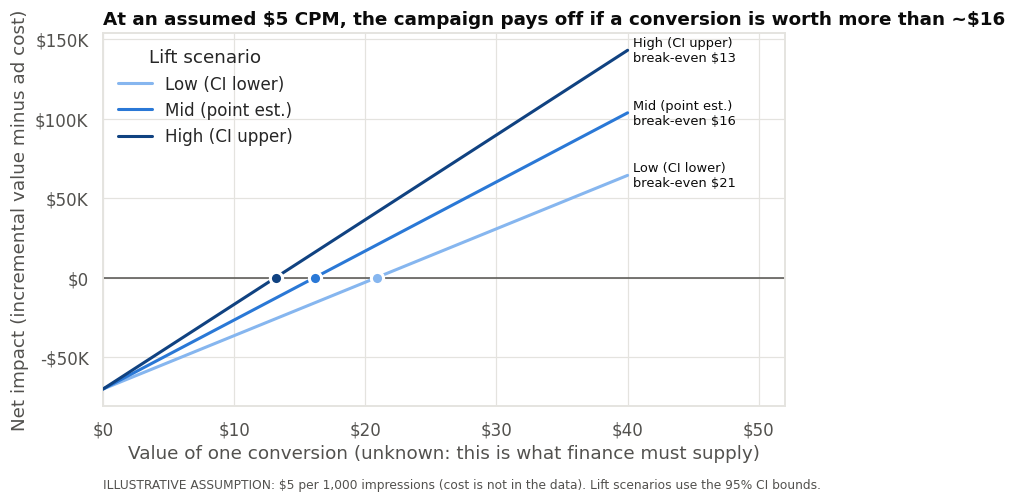

In [25]:
# Net impact across a range of possible conversion values, at the middle CPM assumption.
cpm_mid = CPM_ASSUMED["$5 CPM"]
cost_mid = impressions / 1000 * cpm_mid
values = np.linspace(0, 40, 161)
ramp = {"Low (CI lower)": "#86b6ef", "Mid (point est.)": "#2a78d6", "High (CI upper)": "#104281"}

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.axhline(0, color=INK2, lw=1)
for k, ic in inc_conv.items():
    net = ic * values - cost_mid
    ax.plot(values, net / 1000, color=ramp[k], lw=2, label=k, zorder=3)
    be = cost_mid / ic
    ax.plot(be, 0, "o", ms=8, color=ramp[k], mec="white", mew=2, zorder=4)
    ax.text(values[-1] + 0.4, net[-1] / 1000, f"{k}\nbreak-even ${be:,.0f}", fontsize=8.5, color=INK, va="center")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{'-' if v < 0 else ''}${abs(v):,.0f}K" if v else "$0"))
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_xlim(0, 52)
ax.set_xlabel("Value of one conversion (unknown: this is what finance must supply)")
ax.set_ylabel("Net impact (incremental value minus ad cost)")
ax.legend(title="Lift scenario", loc="upper left")
ax.set_title(f"At an assumed ${cpm_mid:.0f} CPM, the campaign pays off if a conversion is worth more than ~${cost_mid/inc_conv['Mid (point est.)']:,.0f}")
ax.text(0, -0.22, f"ILLUSTRATIVE ASSUMPTION: ${cpm_mid:.0f} per 1,000 impressions (cost is not in the data). "
        "Lift scenarios use the 95% CI bounds.", transform=ax.transAxes, fontsize=8, color=INK2)
fig.savefig(FIG / "08_impact_scenarios.png")
plt.show()

## 6. Recommendation

**Decision: continue the campaign, conditional on one number from finance, and keep a
randomized holdout.**

**Why.**

1. The ad clearly raises conversion. The lift is large in relative terms, its entire 95%
   interval is above zero, and it survives a bootstrap check, an exposure-adjusted model, and an
   independent re-run in R.
2. Whether it *pays* depends on the value of a conversion, which is not in the data. The
   break-even table turns that into one question: is a conversion worth more than the break-even
   value for the real CPM? If yes, keep running; if not, stop or renegotiate media costs.
3. Keep a randomized holdout of about 10% (larger than today's ~4%) with a defined measurement
   window, so the team can keep measuring lift and catch it if it fades.
4. Spend may be concentrated where it does little. Light-exposure users show no detectable lift,
   while the gap appears among heavily exposed users. Before scaling spend, test ad frequency
   directly (see the follow-up design below).

**What would change this decision.**

* A value per conversion below the break-even value at the real CPM → stop or cut spend.
* Evidence that lift fades over time (novelty effect). This data has no timestamps to check.
* A harm signal on a guardrail metric (unsubscribes, complaints) that this data does not track.

**Risks and limitations**

| Risk | Why it matters | Mitigation |
|---|---|---|
| Lopsided 96/4 split, intended ratio unknown | Cannot test for sample ratio mismatch; precision limited by the small group | Document the intended split in the next test and run an SRM check |
| No time dimension | Cannot see duration, novelty effects, or day-of-test trends | Log assignment and conversion timestamps; fix the test length in advance |
| No cost or revenue data | Impact depends on assumptions | Break-even framing; get CPM and conversion value from finance |
| Exposure measured after assignment | Segment findings may reflect user engagement, not ad effects | Keep segments exploratory; test frequency caps with randomization |
| Small exposure differences between groups | Groups were served on slightly different schedules | Adjusted model gives a similar lift; check ad-serving logic |
| No guardrail metrics | Cannot rule out harm | Add unsubscribe/complaint metrics to the next test |

**Follow-up test design.** A balanced or 90/10 split with the intended ratio written down,
timestamps logged, a fixed duration of at least two full weeks (to cover weekly cycles), guardrail
metrics defined in advance, and randomized frequency arms (for example low, medium and high ad
caps) to answer the "do more ads cause more conversions" question properly. That test decides
whether money should shift toward fewer users at higher frequency or wider reach.

In [26]:
def to_py(o):
    if isinstance(o, dict): return {k: to_py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [to_py(v) for v in o]
    if isinstance(o, np.generic): return o.item()
    return o

(REPORTS / "results.json").write_text(json.dumps(to_py(results), indent=2))
seg.to_csv(REPORTS / "segment_results.csv", index=False)
print(f"Saved {len(results)} headline values to reports/results.json")
print("Figures:", sorted(p.name for p in FIG.glob("*.png")))

Saved 36 headline values to reports/results.json
Figures: ['01_conversion_by_group.png', '02_bootstrap_lift.png', '03_lift_by_day.png', '04_lift_by_daypart.png', '05_lift_by_exposure.png', '06_power_curve.png', '07_conversion_by_hour.png', '08_impact_scenarios.png']
